<a href="https://colab.research.google.com/github/Rezkydesyafa/Paddy-Disease-Classification-CNN/blob/main/notebook_paddy_v2_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Paddy Disease Classification

- **Nama:** Mohamad Dwi Rezky Desyafa
- **Email:** rezkydesyafa@gmail.com
- **ID asah :** AE486B6Y1020

Notebook ini mengimplementasikan klasifikasi penyakit padi (*paddy disease*)
menggunakan **Convolutional Neural Network (CNN)** dengan arsitektur
**EfficientNetV2B3** sebagai backbone melalui teknik *transfer learning*.

Dataset yang digunakan berasal dari kompetisi Kaggle
[Paddy Disease Classification](https://www.kaggle.com/competitions/paddy-disease-classification)
dengan total **10.407 gambar** yang terdiri dari **10 kelas** penyakit padi.

### Alur Kerja Notebook
1. **Data Preparation** — Download, validasi, dan eksplorasi dataset
2. **Data Preprocessing** — Split 70:15:15, augmentasi, dan normalisasi
3. **Modelling** — Hyperparameter tuning + training bertahap (3 stage)
4. **Evaluasi** — Akurasi, classification report, dan confusion matrix
5. **Konversi Model** — Ekspor ke SavedModel, TF-Lite, dan TensorFlow.js
6. **Inference** — Bukti prediksi menggunakan model TF-Lite

> Target: training, validation, dan testing accuracy masing-masing minimal **95%**.

## Import Semua Packages/Library yang Digunakan

Seluruh import diletakkan pada satu cell di awal notebook untuk meningkatkan
keterbacaan kode. Berikut library utama yang digunakan:

| Library | Fungsi |
|---------|--------|
| `tensorflow` / `keras` | Framework deep learning untuk membangun dan melatih model CNN |
| `keras_tuner` | Pencarian hyperparameter head secara otomatis via Bayesian Optimization |
| `kagglehub` | Download dataset dari kompetisi Kaggle |
| `matplotlib` | Visualisasi plot akurasi, loss, dan confusion matrix |
| `numpy` / `pandas` | Manipulasi data numerik dan tabular |
| `scikit-learn` | Split dataset (stratified), classification report, confusion matrix |
| `PIL` (Pillow) | Membaca dan memeriksa resolusi gambar asli |
| `tensorflowjs` | Konversi model ke format TensorFlow.js |

Konstanta global (seed, image size, batch size, target akurasi, dan hyperparameter
training) juga didefinisikan di cell ini agar mudah diubah tanpa mencari di
seluruh notebook. Mixed precision (`float16`) diaktifkan jika GPU tersedia
untuk mempercepat training.

In [ ]:
import gc
import importlib.util
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    'kagglehub': 'kagglehub',
    'tensorflowjs': 'tensorflowjs',
    'keras_tuner': 'keras-tuner'
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import kagglehub
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (Activation, BatchNormalization, Conv2D, Dense,
                                     Dropout, GlobalAveragePooling2D, MaxPooling2D,
                                     Rescaling)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
TARGET_ACCURACY = 0.95
ROBUST_VALIDATION_TARGET = 0.975

TUNER_MAX_TRIALS = 6
TUNER_EPOCHS = 10
HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 35
DEEP_FINE_TUNE_EPOCHS = 20
FINE_TUNE_FRACTION = 0.60

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow version:', tf.__version__)
print('Keras Tuner version:', kt.__version__)
print('GPU devices:', gpu_devices)
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy())

TensorFlow version: 2.20.0
Keras Tuner version: 1.4.8
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


## Autentikasi Kaggle API

Sebelum mengunduh dataset, Kaggle API perlu dikonfigurasi dengan menyalin file
`kaggle.json` (berisi API key) ke direktori `~/.kaggle/`. File ini diperlukan
agar `kagglehub` dapat mengakses dan mengunduh dataset dari kompetisi Kaggle
secara otomatis.

> **Catatan:** Pastikan file `kaggle.json` sudah di-upload ke runtime Colab
> sebelum menjalankan cell berikut.

In [ ]:
# Pindahkan kaggle.json ke lokasi yang digunakan Kaggle API.
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle API key berhasil dikonfigurasi!')

Kaggle API key berhasil dikonfigurasi!


## Data Preparation

Dataset tetap diunduh dari kompetisi Paddy Disease Classification melalui
`kagglehub`. Train, validation, dan test hanya berasal dari data berlabel
`train.csv` dan `train_images`; `test_images` Kaggle tidak digunakan untuk evaluasi.

### Data Loading

Dataset diunduh dari kompetisi Kaggle **Paddy Disease Classification** melalui
`kagglehub`. Pada tahap ini dilakukan:

1. **Validasi file** — Memastikan `train.csv` dan folder `train_images` tersedia
2. **Pembuatan filepath** — Menggabungkan path folder dengan nama file dari CSV
3. **Audit resolusi gambar asli** — Memeriksa resolusi **seluruh 10.407 gambar**
   sebelum preprocessing untuk membuktikan bahwa dataset memiliki resolusi yang
   tidak seragam (kriteria penilaian tinggi)
4. **Visualisasi** — Menampilkan distribusi resolusi, contoh gambar per orientasi,
   dan sampel gambar dari setiap kelas penyakit

> **Penting:** Hanya data berlabel dari `train_images` yang digunakan.
> Folder `test_images` dari Kaggle **tidak** digunakan untuk evaluasi.

100%|██████████| 1.02G/1.02G [00:10<00:00, 102MB/s] 

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/paddy-disease-classification
Isi folder dataset: ['sample_submission.csv', 'test_images', 'train.csv', 'train_images']
Catatan: test_images Kaggle tidak digunakan untuk evaluasi: True
Contoh data:


,image_id,label,variety,age,filepath
0,100330.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...


Jumlah total gambar: 10407
Jumlah kelas: 10


,jumlah_gambar
label,
bacterial_leaf_blight,479
bacterial_leaf_streak,380
bacterial_panicle_blight,337
blast,1738
brown_spot,965
dead_heart,1442
downy_mildew,620
hispa,1594
normal,1764


Jumlah resolusi unik seluruh gambar asli: 2


,width,height,jumlah_gambar
0,480,640,10403
1,640,480,4


Dataset terbukti memiliki resolusi asli yang tidak seragam sebelum preprocessing.


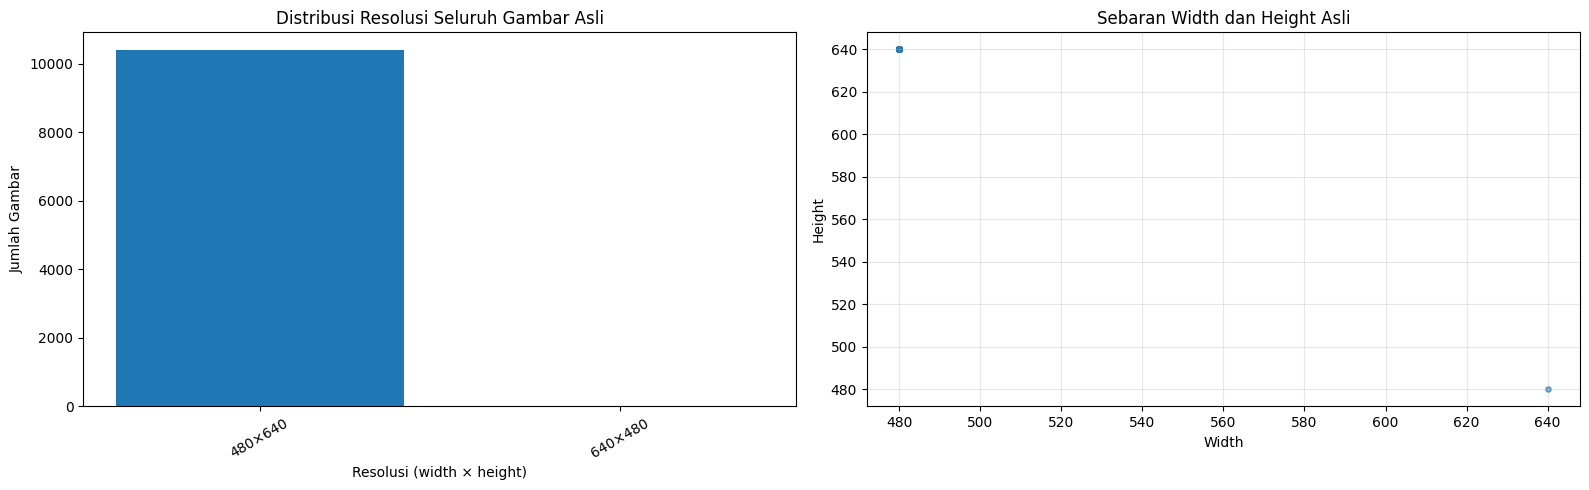

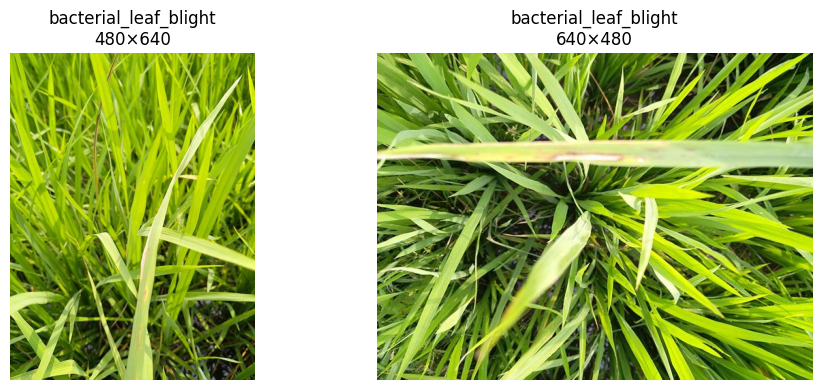

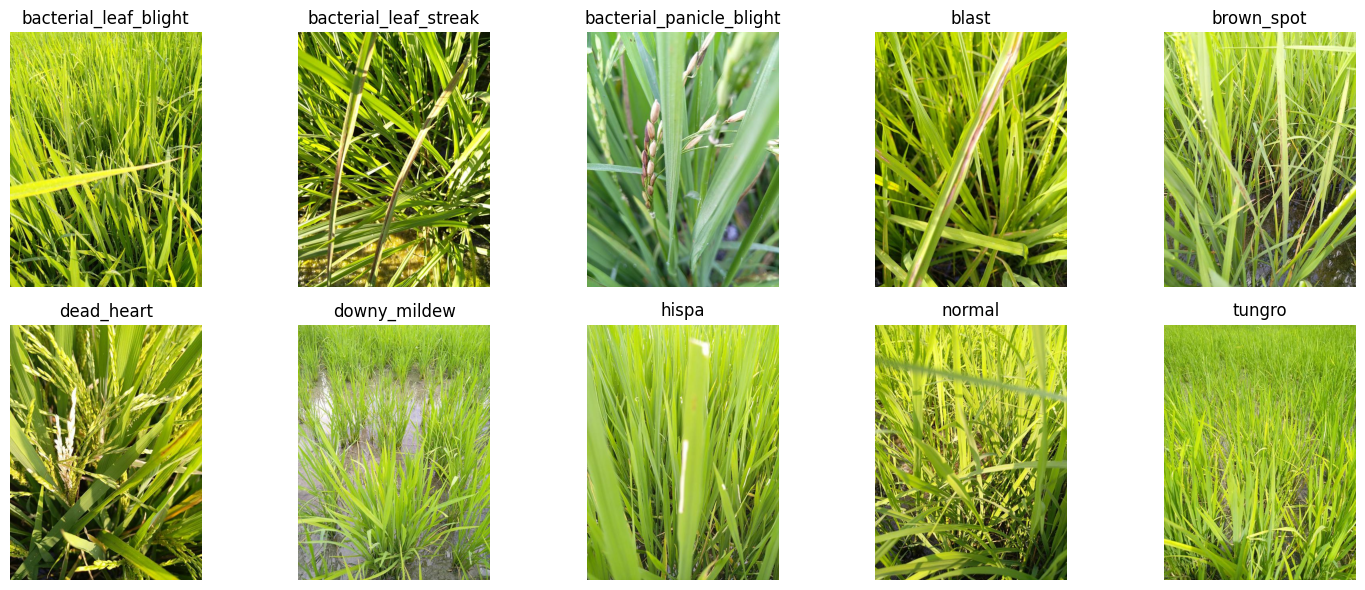

In [ ]:
dataset_path = Path(kagglehub.competition_download('paddy-disease-classification'))
print('Path to competition files:', dataset_path)
print('Isi folder dataset:', sorted(os.listdir(dataset_path)))

train_csv_path = dataset_path / 'train.csv'
train_images_dir = dataset_path / 'train_images'
kaggle_test_images_dir = dataset_path / 'test_images'

assert train_csv_path.exists(), 'train.csv tidak ditemukan.'
assert train_images_dir.exists(), 'train_images tidak ditemukan.'
print('Catatan: test_images Kaggle tidak digunakan untuk evaluasi:', kaggle_test_images_dir.exists())

df = pd.read_csv(train_csv_path)
required_columns = {'image_id', 'label'}
assert required_columns.issubset(df.columns), f'Kolom wajib hilang: {required_columns - set(df.columns)}'

df['filepath'] = df.apply(
    lambda row: str(train_images_dir / row['label'] / row['image_id']),
    axis=1
)
missing_files = df.loc[~df['filepath'].map(lambda file_path: Path(file_path).exists())]
assert missing_files.empty, f'Ada {len(missing_files)} file gambar yang tidak ditemukan.'

print('Contoh data:')
display(df.head())

label_counts = df['label'].value_counts().sort_index()
print('Jumlah total gambar:', len(df))
print('Jumlah kelas:', df['label'].nunique())
display(label_counts.rename('jumlah_gambar').to_frame())

# Audit seluruh gambar asli, bukan sampel dan bukan hasil preprocessing.
resolution_records = []
for file_path in df['filepath']:
    with Image.open(file_path) as image:
        resolution_records.append(image.size)

df[['width', 'height']] = pd.DataFrame(
    resolution_records,
    index=df.index,
    columns=['width', 'height']
)
resolution_counts = (
    df.groupby(['width', 'height'])
      .size()
      .rename('jumlah_gambar')
      .sort_values(ascending=False)
      .reset_index()
)

print('Jumlah resolusi unik seluruh gambar asli:', len(resolution_counts))
display(resolution_counts)
if len(resolution_counts) > 1:
    print('Dataset terbukti memiliki resolusi asli yang tidak seragam sebelum preprocessing.')
else:
    print('Dataset asli hanya memiliki satu resolusi; hasil dilaporkan tanpa manipulasi.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
resolution_labels = (
    resolution_counts['width'].astype(str) + '×' + resolution_counts['height'].astype(str)
)
axes[0].bar(resolution_labels, resolution_counts['jumlah_gambar'])
axes[0].set_title('Distribusi Resolusi Seluruh Gambar Asli')
axes[0].set_xlabel('Resolusi (width × height)')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=30)

axes[1].scatter(df['width'], df['height'], alpha=0.20, s=14)
axes[1].set_title('Sebaran Width dan Height Asli')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

resolution_examples = df.drop_duplicates(subset=['width', 'height']).head(3)
cols = min(3, len(resolution_examples))
plt.figure(figsize=(5 * cols, 4))
for index, row in enumerate(resolution_examples.itertuples(index=False), start=1):
    plt.subplot(1, cols, index)
    plt.imshow(Image.open(row.filepath).convert('RGB'))
    plt.title(f'{row.label}\n{row.width}×{row.height}')
    plt.axis('off')
plt.tight_layout()
plt.show()

sample_images = df.groupby('label', group_keys=False).sample(n=1, random_state=SEED)
cols = 5
rows = math.ceil(len(sample_images) / cols)
plt.figure(figsize=(15, 3 * rows))
for index, row in enumerate(sample_images.itertuples(index=False), start=1):
    plt.subplot(rows, cols, index)
    plt.imshow(Image.open(row.filepath).convert('RGB'))
    plt.title(row.label)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Data Preprocessing

Tahap preprocessing meliputi:

- **Resize**: Semua gambar di-resize ke **300×300** piksel
- **Normalisasi**: Nilai piksel diskalakan ke rentang `[0, 1]` dengan `rescale=1./255`

#### Augmentasi (Hanya pada Data Training)
Augmentasi diterapkan **hanya pada training set** untuk menjaga konsistensi
evaluasi pada validation dan test set:

| Parameter | Nilai | Tujuan |
|-----------|-------|--------|
| `rotation_range` | 15° | Variasi orientasi |
| `zoom_range` | 10% | Variasi jarak pengambilan |
| `width/height_shift` | 5% | Variasi posisi objek |
| `shear_range` | 5% | Distorsi perspektif ringan |
| `brightness_range` | 90-110% | Variasi pencahayaan |
| `horizontal_flip` | True | Variasi simetri horizontal |
| `random_contrast` | 90-110% | Variasi kontras (custom) |

Validation dan test set **hanya** di-resize dan dinormalisasi tanpa augmentasi.

#### Split Dataset

Dataset berlabel dibagi menjadi tiga bagian dengan rasio **70:15:15**
menggunakan `train_test_split` dari scikit-learn:

| Set | Rasio | Fungsi |
|-----|-------|--------|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Memilih checkpoint terbaik dan early stopping |
| **Test** | 15% | Evaluasi akhir (held-out, tidak disentuh saat training) |

Split dilakukan secara **stratified** berdasarkan label untuk memastikan
distribusi kelas yang proporsional di setiap set. Fungsi helper
`make_generator()` digunakan untuk membuat data generator yang konsisten.

In [ ]:
class_names = sorted(df['label'].unique())

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

split_distribution = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'validation': val_df['label'].value_counts().sort_index(),
    'test': test_df['label'].value_counts().sort_index()
}).fillna(0).astype(int)
display(split_distribution)

assert not train_df['filepath'].str.contains('test_images').any()
assert not val_df['filepath'].str.contains('test_images').any()
assert not test_df['filepath'].str.contains('test_images').any()


def random_contrast(image):
    """Apply mild contrast augmentation while preserving the 0..255 domain."""
    factor = np.random.uniform(0.90, 1.10)
    channel_mean = image.mean(axis=(0, 1), keepdims=True)
    return np.clip((image - channel_mean) * factor + channel_mean, 0.0, 255.0)


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    brightness_range=(0.90, 1.10),
    horizontal_flip=True,
    fill_mode='reflect',
    preprocessing_function=random_contrast
)
eval_datagen = ImageDataGenerator(rescale=1./255)


def make_generator(dataframe, datagen, shuffle, batch_size=BATCH_SIZE):
    """Create a class-order-consistent dataframe generator."""
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='filepath',
        y_col='label',
        classes=class_names,
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED if shuffle else None
    )


train_generator = make_generator(train_df, train_datagen, shuffle=True)
train_eval_generator = make_generator(train_df, eval_datagen, shuffle=False)
val_generator = make_generator(val_df, eval_datagen, shuffle=False)
test_generator = make_generator(test_df, eval_datagen, shuffle=False)

class_indices = train_generator.class_indices
index_to_label = {index: label for label, index in class_indices.items()}
class_names_by_index = [index_to_label[index] for index in range(len(index_to_label))]
print('class_indices:', class_indices)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_generator.classes), weights)
}
print('Class weight hasil audit:', class_weights)
print('Class weight tidak diterapkan; run sebelumnya menunjukkan model masih underfit.')

Train: 7284
Validation: 1561
Test: 1562


,train,validation,test
label,,,
bacterial_leaf_blight,335,72,72
bacterial_leaf_streak,266,57,57
bacterial_panicle_blight,236,51,50
blast,1216,261,261
brown_spot,675,145,145
dead_heart,1009,216,217
downy_mildew,434,93,93
hispa,1116,239,239
normal,1235,264,265


Found 7284 validated image filenames belonging to 10 classes.
Found 7284 validated image filenames belonging to 10 classes.
Found 1561 validated image filenames belonging to 10 classes.
Found 1562 validated image filenames belonging to 10 classes.
class_indices: {'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}
Class weight hasil audit: {0: 2.1743283582089554, 1: 2.738345864661654, 2: 3.0864406779661016, 3: 0.5990131578947369, 4: 1.0791111111111111, 5: 0.7219028741328047, 6: 1.6783410138248849, 7: 0.6526881720430108, 8: 0.5897975708502025, 9: 0.9559055118110236}
Class weight tidak diterapkan; run sebelumnya menunjukkan model masih underfit.


## Modelling

### Arsitektur Model
Model dibangun menggunakan `Sequential` dengan komponen berikut:

| Layer | Detail |
|-------|--------|
| `Rescaling` | Normalisasi input ke rentang [-1, 1] untuk EfficientNet |
| **EfficientNetV2B3** | Backbone pretrained ImageNet (frozen saat awal) |
| `Conv2D` (1×1) | Projection layer 768 filter + L2 regularization |
| `BatchNormalization` | Stabilisasi distribusi aktivasi |
| `MaxPooling2D` | Reduce spatial dimensions (memenuhi kriteria rubrik) |
| `GlobalAveragePooling2D` | Agregasi fitur spasial |
| `Dense` + `Dropout` | Classifier head dengan regularisasi |
| `Dense` (softmax) | Output 10 kelas |

### Strategi Training (3 Tahap)
1. **Stage 1 — Feature Extraction**: Backbone frozen, hanya head yang dilatih
2. **Stage 2 — Fine-Tuning 60%**: Membuka 60% layer backbone (BN tetap frozen)
3. **Stage 3 — Full Fine-Tuning**: Membuka seluruh backbone (opsional, hanya
   jika validation accuracy belum mencapai 97,5%)

### Hyperparameter Tuning
Keras Tuner (Bayesian Optimization) digunakan untuk mencari hyperparameter
head secara efisien melalui **cached features** — fitur ImageNet di-extract
satu kali, lalu tuning dilakukan pada array kecil tanpa melatih backbone
berulang kali.

### Callbacks
- `EarlyStopping` — Hentikan training jika validation accuracy tidak membaik
- `ReduceLROnPlateau` — Turunkan learning rate saat loss stagnan
- `ModelCheckpoint` — Simpan model terbaik berdasarkan validation accuracy

In [ ]:
num_classes = len(class_names_by_index)


def build_backbone(weights='imagenet', pooling=None):
    """Create the EfficientNetV2B3 ImageNet feature extractor."""
    return tf.keras.applications.EfficientNetV2B3(
        include_top=False,
        weights=weights,
        input_shape=(*IMG_SIZE, 3),
        pooling=pooling,
        include_preprocessing=False
    )


def build_feature_head(hp):
    """Build the inexpensive dense head used for cached-feature tuning."""
    dense_units = hp.Choice('dense_units', [384, 512, 768])
    dropout_rate = hp.Choice('dropout_rate', [0.15, 0.20, 0.25])
    l2_strength = hp.Choice('l2_strength', [1e-6, 1e-5, 5e-5])
    head_learning_rate = hp.Choice('head_learning_rate', [3e-4, 1e-3])

    head = Sequential([
        tf.keras.Input(shape=(1536,)),
        Dense(
            dense_units,
            activation='swish',
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax', dtype='float32')
    ])
    head.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=head_learning_rate,
            weight_decay=l2_strength
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
        metrics=['accuracy']
    )
    return head


# Cache pooled ImageNet features sekali; tuning berikutnya berlangsung pada array kecil.
tuning_backbone = build_backbone(weights='imagenet', pooling='avg')
tuning_backbone.trainable = False
feature_extractor = Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    Rescaling(scale=2.0, offset=-1.0),
    tuning_backbone
], name='cached_feature_extractor')

train_eval_generator.reset()
val_generator.reset()
train_features = feature_extractor.predict(train_eval_generator, verbose=1)
val_features = feature_extractor.predict(val_generator, verbose=1)
train_targets = tf.keras.utils.to_categorical(train_eval_generator.classes, num_classes)
val_targets = tf.keras.utils.to_categorical(val_generator.classes, num_classes)

tuner = kt.BayesianOptimization(
    hypermodel=build_feature_head,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_trials=TUNER_MAX_TRIALS,
    seed=SEED,
    overwrite=True,
    directory='keras_tuner_results',
    project_name='paddy_cached_features_v2'
)
tuner.search(
    train_features,
    train_targets,
    validation_data=(val_features, val_targets),
    batch_size=128,
    epochs=TUNER_EPOCHS,
    callbacks=[EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=3,
        restore_best_weights=True
    )],
    verbose=1
)

best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
best_config = dict(best_hyperparameters.values)
best_config['projection_filters'] = 768
best_config['label_smoothing'] = 0.01
print('Hyperparameter terbaik:', best_config)

tuner_rows = []
for trial_id, trial in tuner.oracle.trials.items():
    tuner_rows.append({
        'trial_id': trial_id,
        'val_accuracy': trial.score,
        **trial.hyperparameters.values
    })
display(pd.DataFrame(tuner_rows).sort_values('val_accuracy', ascending=False))

# Bebaskan cached features sebelum training end-to-end.
del feature_extractor, tuning_backbone, train_features, val_features
del train_targets, val_targets, tuner
gc.collect()
tf.keras.backend.clear_session()


def build_model(config, backbone_weights='imagenet', compile_model=True):
    """Build the final rubric-compliant EfficientNetV2B3 classifier."""
    backbone = build_backbone(weights=backbone_weights, pooling=None)
    backbone.trainable = False

    classifier = Sequential([
        tf.keras.Input(shape=(*IMG_SIZE, 3), name='image'),
        Rescaling(scale=2.0, offset=-1.0, name='efficientnet_rescaling'),
        backbone,
        Conv2D(
            config['projection_filters'],
            kernel_size=1,
            padding='same',
            use_bias=False,
            kernel_regularizer=regularizers.l2(config['l2_strength']),
            name='rubric_conv2d'
        ),
        BatchNormalization(name='head_batch_norm'),
        Activation('swish', name='head_activation'),
        MaxPooling2D(pool_size=2, padding='same', name='rubric_max_pooling'),
        GlobalAveragePooling2D(name='global_average_pooling'),
        Dense(
            config['dense_units'],
            activation='swish',
            kernel_regularizer=regularizers.l2(config['l2_strength']),
            name='classifier_dense'
        ),
        Dropout(config['dropout_rate'], name='classifier_dropout'),
        Dense(num_classes, activation='softmax', dtype='float32', name='predictions')
    ], name='paddy_disease_efficientnetv2b3')

    if compile_model:
        classifier.compile(
            optimizer=tf.keras.optimizers.AdamW(
                learning_rate=config['head_learning_rate'],
                weight_decay=config['l2_strength'],
                clipnorm=1.0
            ),
            loss=tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=config['label_smoothing']
            ),
            metrics=['accuracy']
        )
    return classifier


def find_backbone(classifier):
    """Return the nested EfficientNetV2 backbone."""
    for layer in classifier.layers:
        if isinstance(layer, tf.keras.Model) and 'efficientnetv2' in layer.name:
            return layer
    raise ValueError('Backbone EfficientNetV2 tidak ditemukan.')


def make_callbacks(checkpoint_path, patience):
    """Create validation-only model-selection callbacks."""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=patience,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.4,
            patience=3,
            min_lr=2e-7,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1
        )
    ]


def enable_fine_tuning(classifier, trainable_fraction):
    """Unfreeze a backbone fraction while freezing all BatchNormalization layers."""
    backbone = find_backbone(classifier)
    backbone.trainable = True
    cutoff = int(len(backbone.layers) * (1.0 - trainable_fraction))
    for index, layer in enumerate(backbone.layers):
        layer.trainable = index >= cutoff and not isinstance(layer, BatchNormalization)
    return backbone, cutoff


def compile_fine_tuning(classifier, learning_rate):
    """Recompile after changing backbone trainability."""
    classifier.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=best_config['l2_strength'],
            clipnorm=1.0
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=best_config['label_smoothing']
        ),
        metrics=['accuracy']
    )


model = build_model(best_config)
assert isinstance(model, tf.keras.Sequential)
assert any(isinstance(layer, Conv2D) for layer in model.layers)
assert any(isinstance(layer, MaxPooling2D) for layer in model.layers)
model.summary()

checkpoint_paths = {}
history_parts = []

# Stage 1: latih head sampai stabil.
stage1_path = Path('best_stage1_v2.keras')
train_generator.reset()
val_generator.reset()
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=HEAD_EPOCHS,
    callbacks=make_callbacks(stage1_path, patience=4)
)
checkpoint_paths['stage_1_feature_extraction'] = stage1_path
history_parts.append(history_stage1.history)

# Stage 2: LR lebih besar daripada run gagal, tetapi tetap aman untuk pretrained weights.
model = tf.keras.models.load_model(stage1_path)
backbone, cutoff = enable_fine_tuning(model, FINE_TUNE_FRACTION)
compile_fine_tuning(model, learning_rate=3e-5)
print(
    f'Stage 2 membuka {len(backbone.layers) - cutoff}/{len(backbone.layers)} '
    'layer backbone; BatchNormalization tetap frozen.'
)

stage2_path = Path('best_stage2_v2.keras')
train_generator.reset()
val_generator.reset()
history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=make_callbacks(stage2_path, patience=8)
)
checkpoint_paths['stage_2_fine_tuning'] = stage2_path
history_parts.append(history_stage2.history)

stage2_model = tf.keras.models.load_model(stage2_path)
val_generator.reset()
stage2_result = stage2_model.evaluate(val_generator, verbose=0, return_dict=True)
print('Stage 2 validation:', stage2_result)

# Stage 3: full fine-tuning hanya jika margin generalisasi belum cukup.
if stage2_result['accuracy'] < ROBUST_VALIDATION_TARGET:
    model = stage2_model
    backbone, cutoff = enable_fine_tuning(model, trainable_fraction=1.0)
    compile_fine_tuning(model, learning_rate=1e-5)
    print('Stage 3 membuka seluruh non-BatchNormalization layer backbone.')

    stage3_path = Path('best_stage3_v2.keras')
    train_generator.reset()
    val_generator.reset()
    history_stage3 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=DEEP_FINE_TUNE_EPOCHS,
        callbacks=make_callbacks(stage3_path, patience=6)
    )
    checkpoint_paths['stage_3_full_fine_tuning'] = stage3_path
    history_parts.append(history_stage3.history)
else:
    print('Stage 3 dilewati karena validation accuracy sudah ≥97,5%.')

# Pilih model hanya dari validation; test set belum disentuh.
checkpoint_rows = []
for stage_name, checkpoint_candidate in checkpoint_paths.items():
    candidate_model = tf.keras.models.load_model(checkpoint_candidate)
    val_generator.reset()
    candidate_result = candidate_model.evaluate(val_generator, verbose=0, return_dict=True)
    checkpoint_rows.append({
        'stage': stage_name,
        'checkpoint': str(checkpoint_candidate),
        'val_accuracy': candidate_result['accuracy'],
        'val_loss': candidate_result['loss']
    })

checkpoint_comparison = pd.DataFrame(checkpoint_rows).sort_values(
    ['val_accuracy', 'val_loss'],
    ascending=[False, True]
)
display(checkpoint_comparison)

checkpoint_path = checkpoint_comparison.iloc[0]['checkpoint']
best_model = tf.keras.models.load_model(checkpoint_path)
print('Best checkpoint loaded from:', checkpoint_path)

Trial 6 Complete [00h 00m 09s]
val_accuracy: 0.877001941204071

Best val_accuracy So Far: 0.8853299021720886
Total elapsed time: 00h 00m 54s
Hyperparameter terbaik: {'dense_units': 512, 'dropout_rate': 0.15, 'l2_strength': 5e-05, 'head_learning_rate': 0.001, 'projection_filters': 768, 'label_smoothing': 0.01}


,trial_id,val_accuracy,dense_units,dropout_rate,l2_strength,head_learning_rate
2,2,0.885330,512,0.15,0.000050,0.0010
5,5,0.877002,384,0.15,0.000050,0.0010
3,3,0.813581,768,0.15,0.000050,0.0003
1,1,0.806534,768,0.20,0.000010,0.0003
0,0,0.800769,512,0.15,0.000010,0.0003
4,4,0.794363,512,0.15,0.000001,0.0003


Model: "paddy_disease_efficientnetv2b3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet_rescaling          │ (None, 300, 300, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rubric_conv2d (Conv2D)          │ (None, 10, 10, 768)    │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 10, 10, 768)    │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_activation (Activation)    │ (None, 10, 10, 768)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rubric_max_pooling              │ (None, 5, 5, 768)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,512,200 (55.36 MB)

 Trainable params: 1,580,042 (6.03 MB)

 Non-trainable params: 12,932,158 (49.33 MB)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.4094 - loss: 1.8606
Epoch 1: val_accuracy improved from None to 0.63229, saving model to best_stage1_v2.keras

Epoch 1: finished saving model to best_stage1_v2.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 340s 636ms/step - accuracy: 0.4901 - loss: 1.5981 - val_accuracy: 0.6323 - val_loss: 1.1952 - learning_rate: 0.0010
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6010 - loss: 1.2866
Epoch 2: val_accuracy improved from 0.63229 to 0.72454, saving model to best_stage1_v2.keras

Epoch 2: finished saving model to best_stage1_v2.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 232s 510ms/step - accuracy: 0.6185 - loss: 1.2451 - val_accuracy: 0.7245 - val_loss: 0.9624 - learning_rate: 0.0010
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.6693 - loss: 1.1152
Epoch 3: val_accuracy improved from 0.72454 to 0.73094, saving model to best_stage1_v2.keras

Epoch 3: finished saving model to best_stage1_v2.keras
45

,stage,checkpoint,val_accuracy,val_loss
1,stage_2_fine_tuning,best_stage2_v2.keras,0.976938,0.316133
0,stage_1_feature_extraction,best_stage1_v2.keras,0.864190,0.649805


Best checkpoint loaded from: best_stage2_v2.keras


## Evaluasi dan Visualisasi

Model terbaik dievaluasi pada **tiga set** (train, validation, test) tanpa
augmentasi untuk mendapatkan metrik yang objektif.

### Metrik yang Ditampilkan
- **Accuracy** per set (target: minimal 95% untuk ketiga set)
- **Classification Report** — Precision, recall, F1-score per kelas
- **Macro-F1 Score** — Rata-rata F1 lintas semua kelas
- **Confusion Matrix** — Visualisasi prediksi benar vs salah per kelas

### Visualisasi Training History
Plot akurasi dan loss dari seluruh tahap training ditampilkan dengan
garis pemisah antar stage untuk melihat dampak setiap tahap fine-tuning.

456/456 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - accuracy: 0.9964 - loss: 0.2266
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9769 - loss: 0.3161
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - accuracy: 0.9706 - loss: 0.3573
Training Accuracy  : 0.9964 (99.64%)
Validation Accuracy: 0.9769 (97.69%)
Testing Accuracy   : 0.9706 (97.06%)
Target train, validation, dan test accuracy minimal 95% TERPENUHI.


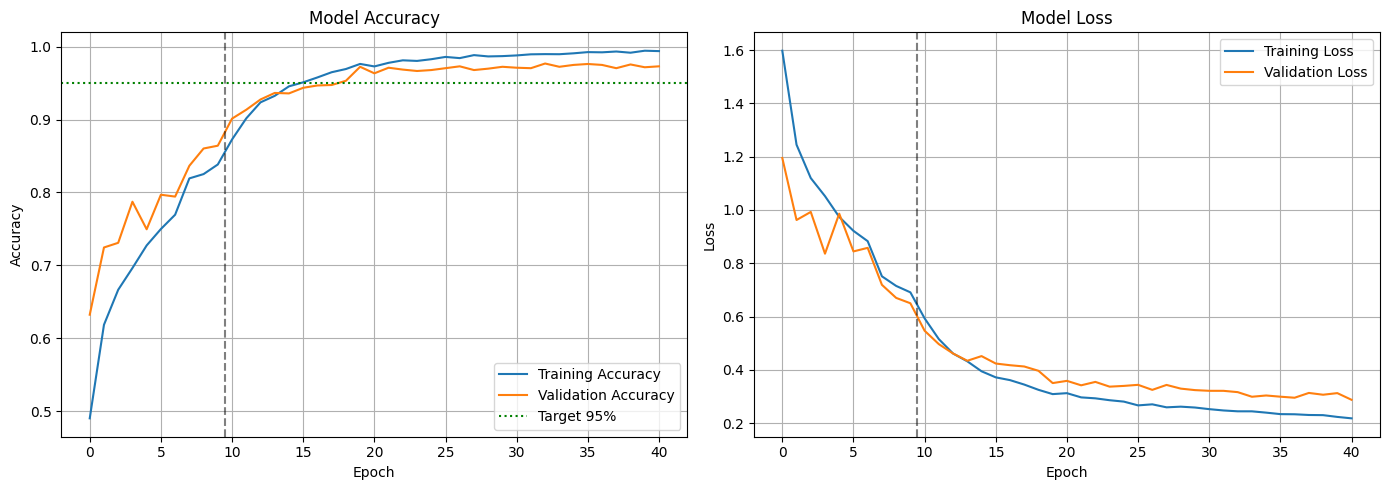

98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step


,precision,recall,f1-score,support
bacterial_leaf_blight,0.922078,0.986111,0.953020,72.000000
bacterial_leaf_streak,0.981818,0.947368,0.964286,57.000000
bacterial_panicle_blight,1.000000,1.000000,1.000000,50.000000
blast,0.969925,0.988506,0.979127,261.000000
brown_spot,0.958904,0.965517,0.962199,145.000000
dead_heart,1.000000,0.995392,0.997691,217.000000
downy_mildew,0.914894,0.924731,0.919786,93.000000
hispa,0.966102,0.953975,0.960000,239.000000
normal,0.988235,0.950943,0.969231,265.000000
tungro,0.964072,0.987730,0.975758,163.000000


Macro-F1: 0.9681


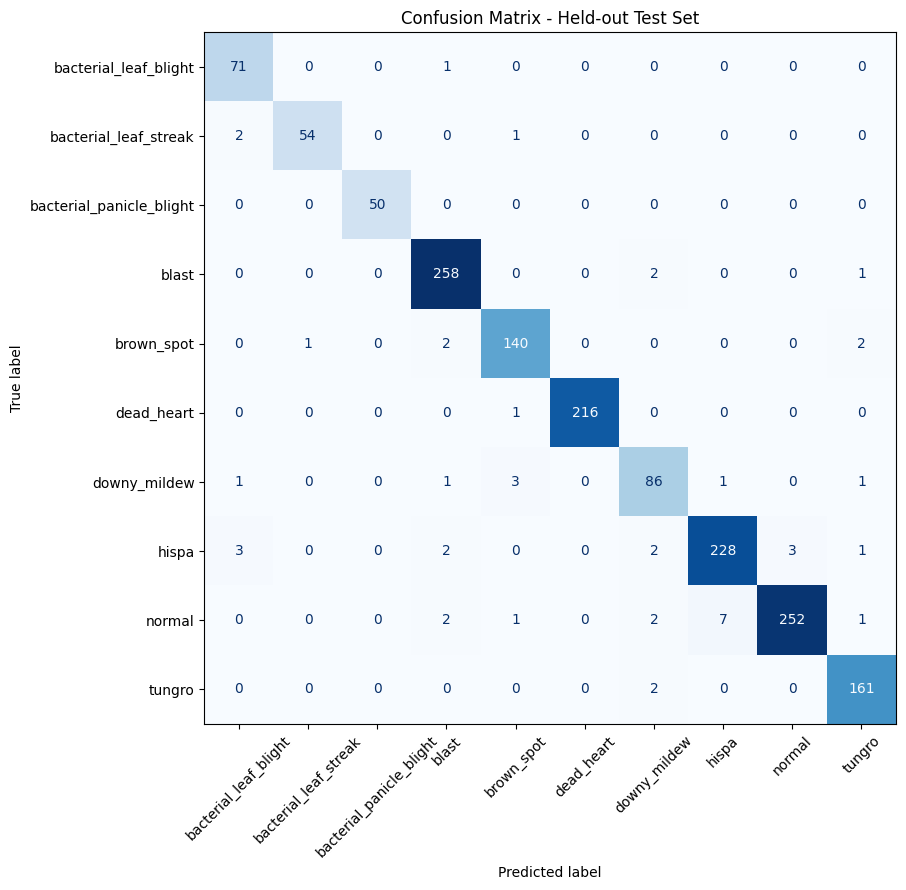

In [ ]:
train_eval_generator.reset()
val_generator.reset()
test_generator.reset()

train_loss, train_acc = best_model.evaluate(train_eval_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print(f'Training Accuracy  : {train_acc:.4f} ({train_acc * 100:.2f}%)')
print(f'Validation Accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)')
print(f'Testing Accuracy   : {test_acc:.4f} ({test_acc * 100:.2f}%)')

if min(train_acc, val_acc, test_acc) >= TARGET_ACCURACY:
    print('Target train, validation, dan test accuracy minimal 95% TERPENUHI.')
else:
    print('Target train, validation, dan test accuracy minimal 95% BELUM TERPENUHI.')

history_all = {
    metric: [
        value
        for history_part in history_parts
        for value in history_part.get(metric, [])
    ]
    for metric in ['accuracy', 'val_accuracy', 'loss', 'val_loss']
}

stage_boundaries = []
completed_epochs = 0
for history_part in history_parts[:-1]:
    completed_epochs += len(history_part.get('loss', []))
    stage_boundaries.append(completed_epochs - 0.5)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_all['accuracy'], label='Training Accuracy')
plt.plot(history_all['val_accuracy'], label='Validation Accuracy')
plt.axhline(TARGET_ACCURACY, color='green', linestyle=':', label='Target 95%')
for boundary in stage_boundaries:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.5)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_all['loss'], label='Training Loss')
plt.plot(history_all['val_loss'], label='Validation Loss')
for boundary in stage_boundaries:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.5)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

test_generator.reset()
pred_probabilities = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probabilities, axis=1)
y_true = test_generator.classes

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names_by_index,
    digits=4,
    output_dict=True
)
report_table = pd.DataFrame(report_dict).transpose()
display(report_table)
print(f"Macro-F1: {report_dict['macro avg']['f1-score']:.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_by_index
).plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d', colorbar=False)
plt.title('Confusion Matrix - Held-out Test Set')
plt.tight_layout()
plt.show()

## Konversi Model

Model yang dilatih dengan mixed-precision (`float16`) perlu direkonstruksi
ke `float32` sebelum diekspor, agar kompatibel dengan semua format target.

### Format Output
| Format | Kegunaan | Lokasi |
|--------|----------|--------|
| **SavedModel** | Deployment di server/cloud | `submission/saved_model/` |
| **TF-Lite** | Perangkat mobile dan embedded | `submission/tflite/model.tflite` |
| **TensorFlow.js** | Aplikasi web/browser | `submission/tfjs_model/` |

Setiap format divalidasi setelah konversi untuk memastikan prediksi konsisten
dengan model asli. Patching otomatis dilakukan pada library `tensorflowjs`
untuk mengatasi inkompatibilitas dengan NumPy 2.x dan Python 3.13.

In [ ]:
submission_dir = Path('submission')
saved_model_dir = submission_dir / 'saved_model'
tflite_dir = submission_dir / 'tflite'
tfjs_dir = submission_dir / 'tfjs_model'

submission_dir.mkdir(exist_ok=True)
for output_dir in [saved_model_dir, tflite_dir, tfjs_dir]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

# Rekonstruksi float32 mencegah ERROR_NEEDS_FLEX_OPS akibat graph mixed-float16.
tf.keras.mixed_precision.set_global_policy('float32')
deployment_model = build_model(
    best_config,
    backbone_weights=None,
    compile_model=False
)
deployment_model.set_weights(best_model.get_weights())

# Pastikan rekonstruksi tidak mengubah kelas prediksi.
test_generator.reset()
comparison_images, _ = next(test_generator)
mixed_predictions = best_model.predict(comparison_images, verbose=0)
float32_predictions = deployment_model.predict(comparison_images, verbose=0)
max_prediction_difference = float(np.max(np.abs(mixed_predictions - float32_predictions)))
label_match = np.array_equal(
    np.argmax(mixed_predictions, axis=1),
    np.argmax(float32_predictions, axis=1)
)
print('Maksimum selisih probabilitas mixed vs float32:', max_prediction_difference)
print('Semua label mixed vs float32 sama:', label_match)
assert label_match, 'Rekonstruksi float32 mengubah label prediksi.'

# SavedModel
if saved_model_dir.exists():
    shutil.rmtree(saved_model_dir)
try:
    deployment_model.export(str(saved_model_dir))
except AttributeError:
    tf.saved_model.save(deployment_model, str(saved_model_dir))

assert (saved_model_dir / 'saved_model.pb').exists()
assert (saved_model_dir / 'variables').exists()
print('SavedModel tersimpan di:', saved_model_dir)

# TensorFlow Lite built-in float32.
converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
tflite_model = converter.convert()
tflite_model_path = tflite_dir / 'model.tflite'
with open(tflite_model_path, 'wb') as file:
    file.write(tflite_model)

label_path = tflite_dir / 'label.txt'
with open(label_path, 'w', encoding='utf-8') as file:
    for label in class_names_by_index:
        file.write(label + '\n')

# Validasi interpreter segera setelah konversi.
export_interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
export_interpreter.allocate_tensors()
export_input = export_interpreter.get_input_details()[0]
export_output = export_interpreter.get_output_details()[0]
single_image = comparison_images[:1].astype(export_input['dtype'])
export_interpreter.set_tensor(export_input['index'], single_image)
export_interpreter.invoke()
tflite_check = export_interpreter.get_tensor(export_output['index'])
assert int(np.argmax(tflite_check[0])) == int(np.argmax(float32_predictions[0]))
print('TFLite tersimpan dan inference tervalidasi di:', tflite_model_path)

# TensorFlow.js - dengan patching untuk kompatibilitas Python 3.13 / NumPy 2.x
# Patch tensorflowjs untuk mengatasi error np.object, np.bool, dan import yang hilang.
tensorflowjs_spec = importlib.util.find_spec('tensorflowjs')
assert tensorflowjs_spec is not None, 'Package tensorflowjs tidak ditemukan.'

tensorflowjs_package_dir = Path(
    next(iter(tensorflowjs_spec.submodule_search_locations))
)

patched_files = []
for python_file in tensorflowjs_package_dir.rglob('*.py'):
    original_text = python_file.read_text(encoding='utf-8')
    patched_text = original_text
    patched_text = re.sub(r'\bnp\.object\b', 'object', patched_text)
    patched_text = re.sub(r'\bnp\.bool\b', 'np.bool_', patched_text)
    patched_text = re.sub(
        r'(?m)^import tensorflow_hub as hub\s*$',
        'hub = None  # Disabled: not required for SavedModel conversion',
        patched_text
    )
    patched_text = re.sub(
        r'(?m)^import tensorflow_decision_forests\s*$',
        'tensorflow_decision_forests = None  # Disabled: not required for SavedModel conversion',
        patched_text
    )
    if patched_text != original_text:
        python_file.write_text(patched_text, encoding='utf-8')
        patched_files.append(str(python_file))

print('File tensorflowjs yang diperbaiki:', len(patched_files))

# Pastikan signature SavedModel tersedia.
loaded_saved_model = tf.saved_model.load(str(saved_model_dir))
available_signatures = list(loaded_saved_model.signatures.keys())
print('SavedModel signatures:', available_signatures)
assert 'serving_default' in available_signatures, 'Signature serving_default tidak ditemukan.'

# Bersihkan hasil TFJS yang mungkin parsial, lalu konversi ulang.
if tfjs_dir.exists():
    shutil.rmtree(tfjs_dir)
tfjs_dir.mkdir(parents=True, exist_ok=True)

tfjs_converter = shutil.which('tensorflowjs_converter')
assert tfjs_converter is not None, 'tensorflowjs_converter tidak ditemukan.'

tfjs_command = [
    tfjs_converter,
    '--input_format=tf_saved_model',
    '--output_format=tfjs_graph_model',
    '--signature_name=serving_default',
    '--saved_model_tags=serve',
    '--weight_shard_size_bytes=104857600',
    str(saved_model_dir),
    str(tfjs_dir)
]

print('Mengonversi SavedModel float32 menjadi TFJS GraphModel...')
conversion_result = subprocess.run(tfjs_command, capture_output=True, text=True)
if conversion_result.stdout:
    print(conversion_result.stdout)
if conversion_result.returncode != 0:
    print('STDERR:', conversion_result.stderr)
    raise RuntimeError('Konversi SavedModel ke TFJS gagal.\n' + conversion_result.stderr)

model_json_path = tfjs_dir / 'model.json'
tfjs_weight_files = list(tfjs_dir.glob('*.bin'))
assert model_json_path.exists(), 'TFJS model.json tidak ditemukan.'
assert tfjs_weight_files, 'Weight shard TFJS tidak ditemukan.'
print('TFJS GraphModel berhasil dibuat di:', tfjs_dir)
print('Jumlah weight shard:', len(tfjs_weight_files))

# Salin notebook ke nama baku dalam submission.
notebook_destination = submission_dir / 'notebook.ipynb'
copied_notebook = False
for candidate in [Path('notebook_paddy_v2.ipynb'), Path('notebook.ipynb')]:
    if candidate.exists():
        shutil.copy(candidate, notebook_destination)
        copied_notebook = True
        break
if not copied_notebook:
    try:
        from google.colab import _message
        notebook_payload = _message.blocking_request('get_ipynb', timeout_sec=10)
        with open(notebook_destination, 'w', encoding='utf-8') as file:
            json.dump(notebook_payload['ipynb'], file)
        copied_notebook = True
    except Exception as error:
        print('Notebook aktif belum dapat disalin otomatis:', error)

readme_text = """# Smart Farming Rice Disease Detection Using CNN

EfficientNetV2B3 transfer learning dengan cached-feature Keras Tuner dan fine-tuning bertahap.
Dataset: Paddy Disease Classification dari Kaggle.

## Dataset Split
- Train: 70% | Validation: 15% | Test: 15%
- Input: 300x300
- Model: Sequential + EfficientNetV2B3 + Conv2D + MaxPooling2D

## Output
- SavedModel: submission/saved_model
- TFLite: submission/tflite/model.tflite
- TFJS: submission/tfjs_model
"""
requirements_text = """tensorflow
tensorflowjs
keras-tuner
numpy
pandas
matplotlib
scikit-learn
pillow
kagglehub
"""

with open(submission_dir / 'README.md', 'w', encoding='utf-8') as file:
    file.write(readme_text)
with open(submission_dir / 'requirements.txt', 'w', encoding='utf-8') as file:
    file.write(requirements_text)

expected_paths = [
    tfjs_dir / 'model.json',
    tflite_model_path,
    label_path,
    saved_model_dir / 'saved_model.pb',
    saved_model_dir / 'variables',
    notebook_destination,
    submission_dir / 'README.md',
    submission_dir / 'requirements.txt'
]
assert list(tfjs_dir.glob('*.bin')), 'Weight shard TFJS tidak ditemukan.'
missing_paths = [str(path) for path in expected_paths if not path.exists()]
assert not missing_paths, 'Struktur belum lengkap: ' + ', '.join(missing_paths)


def print_tree(root_path):
    """Print an indented directory tree for submission verification."""
    root_path = Path(root_path)
    print(root_path.name)
    for current_root, dirs, files in os.walk(root_path):
        current_root = Path(current_root)
        dirs.sort()
        files.sort()
        level = len(current_root.relative_to(root_path).parts)
        indent = '    ' * level
        for directory_name in dirs:
            print(f'{indent}|-- {directory_name}')
        for file_name in files:
            print(f'{indent}|-- {file_name}')


print_tree(submission_dir)
archive_path = shutil.make_archive('submission', 'zip', 'submission')
print('Zip berhasil dibuat:', archive_path)

Maksimum selisih probabilitas mixed vs float32: 0.0
Semua label mixed vs float32 sama: True
Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136156182133456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182129424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182133264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182131536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182130960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182133648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182129616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182131344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136156182127504: TensorSpec(shape=(), dtype=tf.resource, name=

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite tersimpan dan inference tervalidasi di: submission/tflite/model.tflite
File tensorflowjs yang diperbaiki: 3
SavedModel signatures: ['serve', 'serving_default']
Mengonversi SavedModel float32 menjadi TFJS GraphModel...
Writing weight file submission/tfjs_model/model.json...

TFJS GraphModel berhasil dibuat di: submission/tfjs_model
Jumlah weight shard: 1
submission
|-- saved_model
|-- tfjs_model
|-- tflite
|-- README.md
|-- notebook.ipynb
|-- requirements.txt
    |-- assets
    |-- variables
    |-- fingerprint.pb
    |-- saved_model.pb
        |-- variables.data-00000-of-00001
        |-- variables.index
    |-- group1-shard1of1.bin
    |-- model.json
    |-- label.txt
    |-- model.tflite
Zip berhasil dibuat: /content/submission.zip


## Inference menggunakan TF-Lite

Bagian ini mendemonstrasikan inference menggunakan file `model.tflite` yang
telah diekspor, **bukan** model Keras di memory. Hal ini membuktikan bahwa
model TF-Lite yang disimpan benar-benar dapat digunakan untuk prediksi.

### Skenario Inference
1. **Single Image** — Prediksi satu gambar dari test set dengan visualisasi
   gambar asli, label aktual, label prediksi, dan confidence score
2. **Batch 5 Gambar** — Prediksi lima gambar sekaligus untuk menunjukkan
   konsistensi performa model TF-Lite

Setelah inference, notebook aktif disalin ke folder submission dan zip
final dibuat untuk keperluan pengumpulan.

INFERENCE MENGGUNAKAN TF-LITE
TFLite Input Shape: [  1 300 300   3]
TFLite Input Dtype: <class 'numpy.float32'>

--- Single Image TF-Lite Inference ---


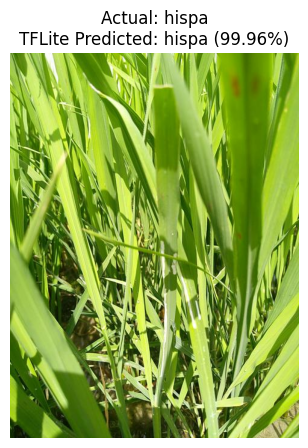

Actual Label      : hispa
TFLite Predicted  : hispa
TFLite Confidence : 99.96%

--- Batch TF-Lite Inference (5 gambar) ---
[OK] Actual: downy_mildew                   | Predicted: downy_mildew                   | Conf: 99.1%
[OK] Actual: blast                          | Predicted: blast                          | Conf: 98.9%
[OK] Actual: blast                          | Predicted: blast                          | Conf: 100.0%
[OK] Actual: dead_heart                     | Predicted: dead_heart                     | Conf: 99.8%
[OK] Actual: tungro                         | Predicted: tungro                         | Conf: 99.9%
Batch accuracy: 5/5

--- Membuat zip final ---
submission
|-- saved_model
|-- tfjs_model
|-- tflite
|-- README.md
|-- notebook.ipynb
|-- requirements.txt
    |-- assets
    |-- variables
    |-- fingerprint.pb
    |-- saved_model.pb
        |-- variables.data-00000-of-00001
        |-- variables.index
    |-- group1-shard1of1.bin
    |-- model.json
    |-- label.t

In [ ]:
# -- Inference menggunakan TF-Lite --
print('=' * 70)
print('INFERENCE MENGGUNAKAN TF-LITE')
print('=' * 70)

tflite_model_path = str(submission_dir / 'tflite' / 'model.tflite')
assert os.path.exists(tflite_model_path), f'File TFLite tidak ditemukan: {tflite_model_path}'

interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('TFLite Input Shape:', input_details[0]['shape'])
print('TFLite Input Dtype:', input_details[0]['dtype'])

# --- Inference gambar tunggal ---
print('\n--- Single Image TF-Lite Inference ---')
sample_row = test_df.sample(n=1, random_state=SEED).iloc[0]
image_path = sample_row['filepath']
actual_label = sample_row['label']

image = Image.open(image_path).convert('RGB')
resized_image = image.resize(IMG_SIZE)
image_array = tf.keras.utils.img_to_array(resized_image) / 255.0
image_array = np.expand_dims(image_array, axis=0).astype(input_details[0]['dtype'])

interpreter.set_tensor(input_details[0]['index'], image_array)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])[0]

tflite_predicted_index = int(np.argmax(tflite_output))
tflite_predicted_label = class_names_by_index[tflite_predicted_index]
tflite_confidence = float(tflite_output[tflite_predicted_index])

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f'Actual: {actual_label}\n'
    f'TFLite Predicted: {tflite_predicted_label} ({tflite_confidence * 100:.2f}%)'
)
plt.axis('off')
plt.show()

print(f'Actual Label      : {actual_label}')
print(f'TFLite Predicted  : {tflite_predicted_label}')
print(f'TFLite Confidence : {tflite_confidence * 100:.2f}%')

# --- Batch inference 5 gambar ---
print('\n--- Batch TF-Lite Inference (5 gambar) ---')
batch_samples = test_df.sample(n=5, random_state=SEED + 1)
correct = 0
for _, row in batch_samples.iterrows():
    batch_image = Image.open(row['filepath']).convert('RGB').resize(IMG_SIZE)
    batch_array = tf.keras.utils.img_to_array(batch_image) / 255.0
    batch_array = np.expand_dims(batch_array, axis=0).astype(input_details[0]['dtype'])
    interpreter.set_tensor(input_details[0]['index'], batch_array)
    interpreter.invoke()
    batch_output = interpreter.get_tensor(output_details[0]['index'])[0]
    predicted_label = class_names_by_index[int(np.argmax(batch_output))]
    confidence = float(np.max(batch_output))
    is_correct = predicted_label == row['label']
    correct += int(is_correct)
    status = 'OK' if is_correct else 'MISS'
    print(
        f"[{status}] Actual: {row['label']:30s} | "
        f"Predicted: {predicted_label:30s} | Conf: {confidence * 100:.1f}%"
    )
print(f'Batch accuracy: {correct}/{len(batch_samples)}')

# Simpan notebook aktif apabila API Colab tersedia, lalu buat zip final.
print('\n--- Membuat zip final ---')
notebook_destination = submission_dir / 'notebook.ipynb'
try:
    from google.colab import _message
    notebook_payload = _message.blocking_request('get_ipynb', timeout_sec=10)
    with open(notebook_destination, 'w', encoding='utf-8') as file:
        json.dump(notebook_payload['ipynb'], file)
except Exception as error:
    if notebook_destination.exists():
        print('Menggunakan notebook.ipynb yang sudah tersedia di folder submission.')
    else:
        print('Notebook aktif belum dapat disalin otomatis:', error)

missing_paths = [str(path) for path in expected_paths if not path.exists()]
assert not missing_paths, 'Struktur belum lengkap: ' + ', '.join(missing_paths)
print_tree(submission_dir)
archive_path = shutil.make_archive('submission', 'zip', 'submission')
print('Zip final berhasil dibuat:', archive_path)